<a href="https://colab.research.google.com/github/bayugilangpamungkas/PCVK_Ganjil_2021/blob/main/244107027020_BAYU_GILANG_PAMUNGKAS_Deteksi_PenyakitDaun_Pada_Tanaman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaustubhb999/tomatoleaf")

print("Path to dataset files:", path)

100%|██████████| 179M/179M [00:01<00:00, 101MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kaustubhb999/tomatoleaf/versions/1


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.1027 - loss: 2.8177 - val_accuracy: 0.1450 - val_loss: 2.2583
Epoch 2/20


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.1450 - val_loss: 2.2583
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.1932 - loss: 2.2325 - val_accuracy: 0.2650 - val_loss: 2.1447
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.2650 - val_loss: 2.1447
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.2273 - loss: 2.1216 - val_accuracy: 0.3800 - val_loss: 1.9448
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.3800 - val_loss: 1.9448
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2888 - loss: 1.9786 - val_accuracy: 0.4350 - val_loss: 1.7640
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.4350 - val_loss: 1.7640
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3777 - loss: 1.8084 - val_acc

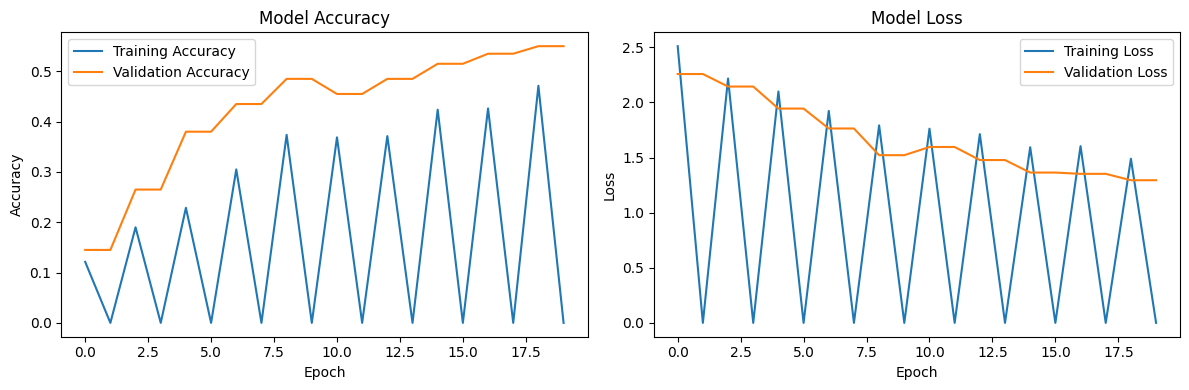

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step
                                               precision    recall  f1-score   support

       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.58      0.95      0.72        20
                      Tomato___Bacterial_spot       0.48      0.77      0.59        13
                        Tomato___Early_blight       0.67      0.15      0.24        27
Tomato___Spider_mites Two-spotted_spider_mite       0.37      0.62      0.46        21
                           Tomato___Leaf_Mold       0.62      0.33      0.43        15
                  Tomato___Septoria_leaf_spot       0.64      0.32      0.42        22
                         Tomato___Target_Spot       0.52      0.64      0.57        25
                 Tomato___Tomato_mosaic_virus       0.72      1.00      0.84        13
                             Tomato___healthy       0.64      0.78      0.71        23
                         Tomato___Late_blight       0.56      0.24      0.33        21

  

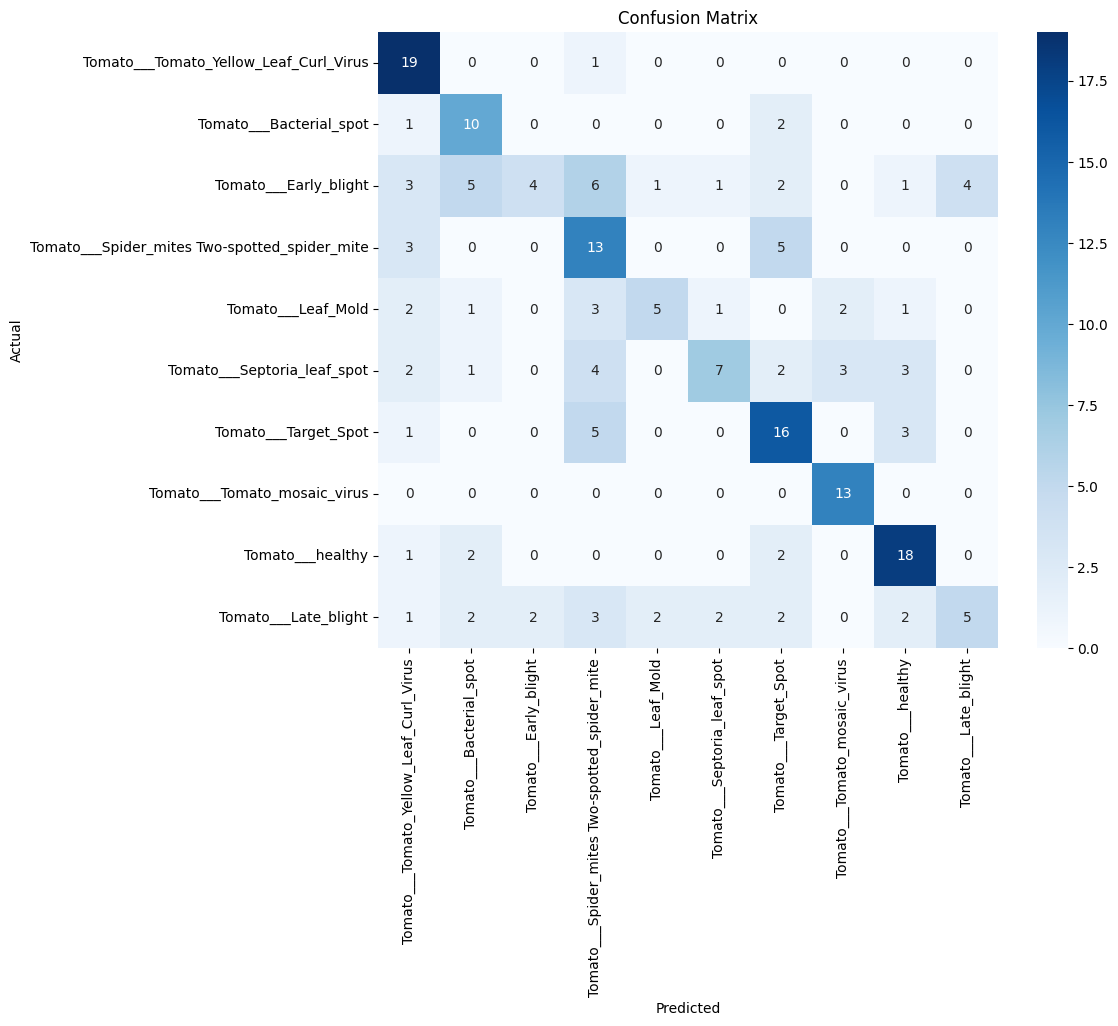

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set up paths
base_dir = '/root/.cache/kagglehub/datasets/kaustubhb999/tomatoleaf/versions/1/tomato'
train_dir = os.path.join(base_dir, 'train')

# Function to load and preprocess images
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    return img / 255.0

# Load a subset of images and labels
images = []
labels = []
label_dict = {}
max_images_per_class = 100  # Limit the number of images per class

for i, disease in enumerate(os.listdir(train_dir)):
    label_dict[i] = disease
    disease_path = os.path.join(train_dir, disease)
    img_count = 0
    for img_name in os.listdir(disease_path):
        if img_count >= max_images_per_class:
            break
        img_path = os.path.join(disease_path, img_name)
        img = load_and_preprocess_image(img_path)
        images.append(img)
        labels.append(i)
        img_count += 1

images = np.array(images)
labels = np.array(labels)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2
)

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_dict), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    steps_per_epoch=len(X_train) // 32
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Make predictions on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Print classification report
print(classification_report(y_test, y_pred_classes, target_names=list(label_dict.values())))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_dict.values(), yticklabels=label_dict.values())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


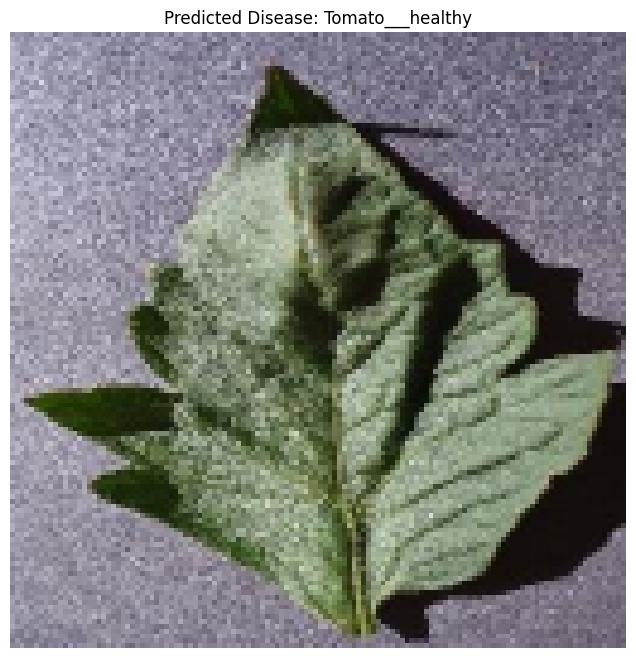

Predicted disease: Tomato___healthy


In [ ]:
# Function to predict disease for a single image
def predict_and_display_disease(image_path):
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)

    # Make prediction
    img_array = np.expand_dims(img, axis=0)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    predicted_disease = label_dict[predicted_class]

    # Display the image and predictiong
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted Disease: {predicted_disease}')
    plt.show()

    return predicted_disease

# Example usage
test_image_path = '/content/daun.JPG'  # Update this path to your specific image
predicted_disease = predict_and_display_disease(test_image_path)
print(f'Predicted disease: {predicted_disease}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


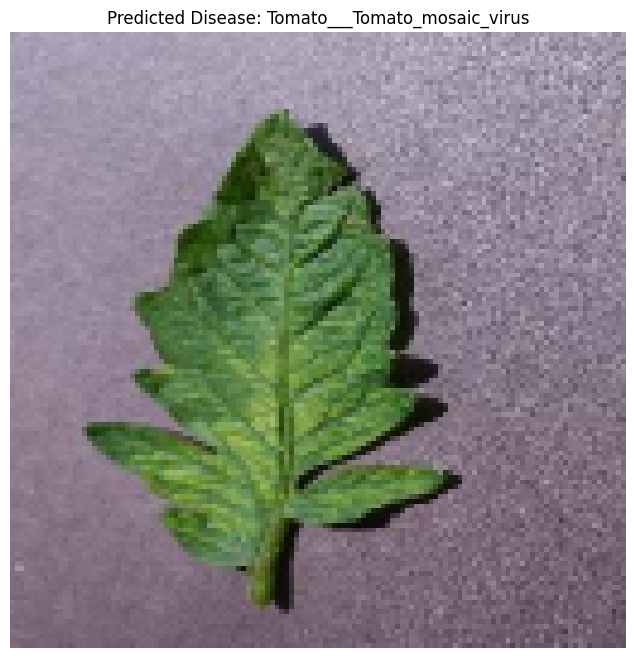

Predicted disease: Tomato___Tomato_mosaic_virus


In [ ]:
# Function to predict disease for a single image
def predict_and_display_disease(image_path):
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)

    # Make prediction
    img_array = np.expand_dims(img, axis=0)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    predicted_disease = label_dict[predicted_class]

    # Display the image and prediction
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted Disease: {predicted_disease}')
    plt.show()

    return predicted_disease

# Example usage
test_image_path = '/content/daun1.JPG'  # Update this path to your specific image
predicted_disease = predict_and_display_disease(test_image_path)
print(f'Predicted disease: {predicted_disease}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


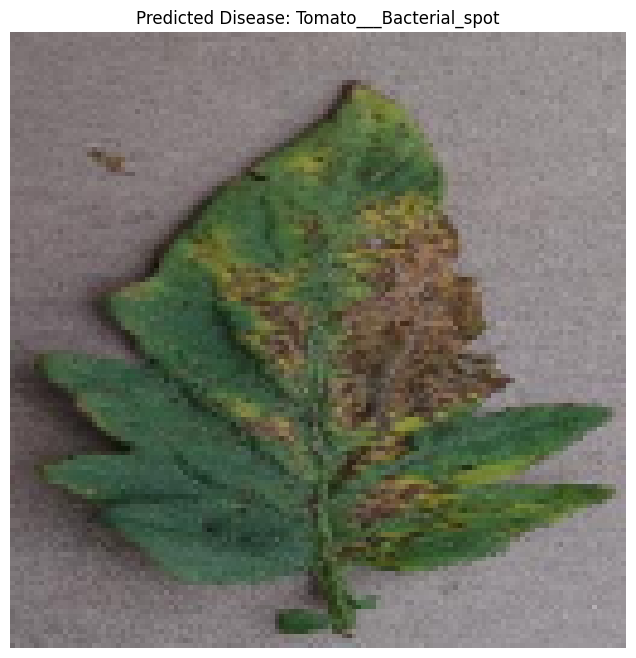

Predicted disease: Tomato___Bacterial_spot


In [ ]:
# Function to predict disease for a single image
def predict_and_display_disease(image_path):
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)

    # Make prediction
    img_array = np.expand_dims(img, axis=0)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    predicted_disease = label_dict[predicted_class]

    # Display the image and prediction
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted Disease: {predicted_disease}')
    plt.show()

    return predicted_disease

# Example usage
test_image_path = '/content/daun2.JPG'  # Update this path to your specific image
predicted_disease = predict_and_display_disease(test_image_path)
print(f'Predicted disease: {predicted_disease}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


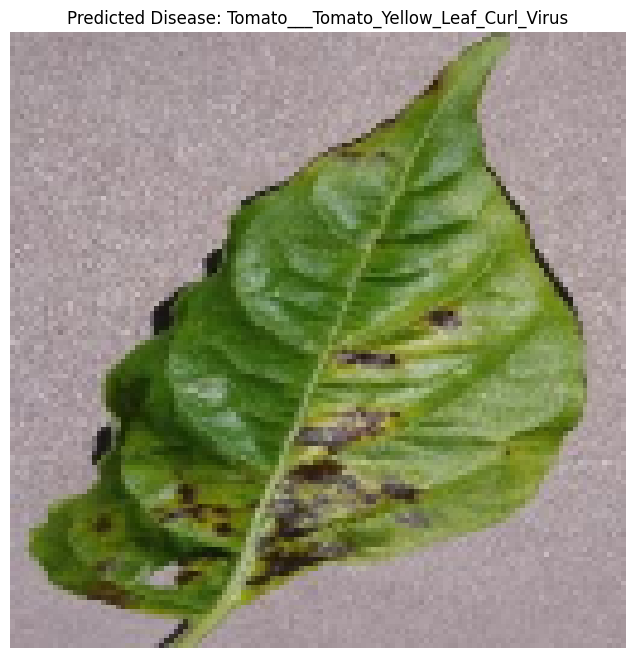

Predicted disease: Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [ ]:
# Function to predict disease for a single image
def predict_and_display_disease(image_path):
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)

    # Make prediction
    img_array = np.expand_dims(img, axis=0)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    predicted_disease = label_dict[predicted_class]

    # Display the image and prediction
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted Disease: {predicted_disease}')
    plt.show()

    return predicted_disease

# Example usage
test_image_path = '/content/daun6.JPG'  # Update this path to your specific image
predicted_disease = predict_and_display_disease(test_image_path)
print(f'Predicted disease: {predicted_disease}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


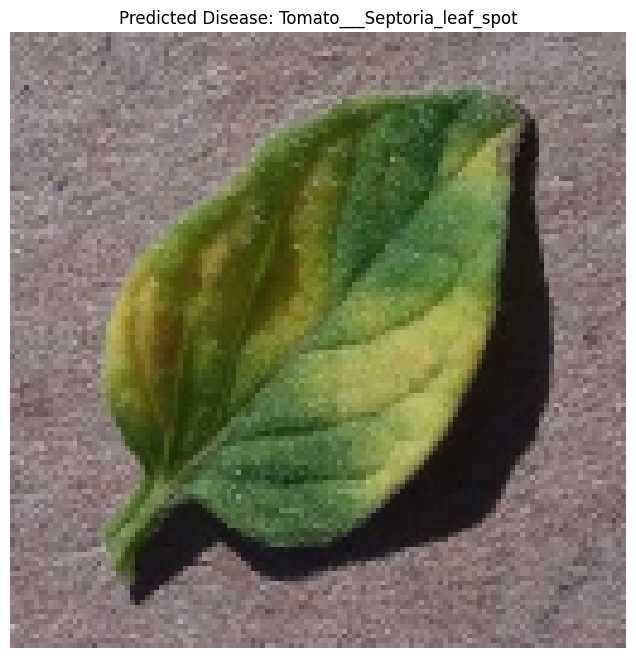

Predicted disease: Tomato___Septoria_leaf_spot


In [ ]:
# Function to predict disease for a single image
def predict_and_display_disease(image_path):
    # Load and preprocess the image
    img = load_and_preprocess_image(image_path)

    # Make prediction
    img_array = np.expand_dims(img, axis=0)
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction, axis=1)[0]
    predicted_disease = label_dict[predicted_class]

    # Display the image and prediction
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted Disease: {predicted_disease}')
    plt.show()

    return predicted_disease

# Example usage
test_image_path = '/content/daun5.JPG'  # Update this path to your specific image
predicted_disease = predict_and_display_disease(test_image_path)
print(f'Predicted disease: {predicted_disease}')